<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/An%C3%A1lisis%20Exploratorio%20y%20Curaci%C3%B3n%20de%20Datos/parte%202/EyCD_2026_Entregable_Parte_2_Grupo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**
Grupo 3:

- BAGGINI, Mariano

- DA SILVA, Rocio

- GRUZYCKI, Sergio

- NEDEL, Agustina

----

# Trabajo práctico entregable - parte 2

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
sns.set_context('talk')
import plotly.express as px

from sqlalchemy import create_engine, text

## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar. Usá `df.dtypes` para ver los tipos actuales. Prestá especial atención a columnas como `Date` y `Price`: por ejemplo, `Date` puede estar como string en vez de datetime, y `Price` puede venir como string o float. El método `to_sql()` infiere tipos automáticamente, pero puede fallar si los tipos no son los esperados.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por `Regionname`.
    - cantidad de registros totales por `Suburb` y `Regionname`.
    - Consulta con filtro: ¿Cuántas propiedades hay por `Regionname` con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (`Type`) y `Regionname`?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL para obtener un resultado similar a lo realizado con Pandas en clase.

6. Agregar una celda de validación posterior al JOIN con assertions o validación de esquema. Como mínimo, verificá que el número de filas no cambió, que no aparecieron nulos inesperados y que los rangos de variables agregadas sean razonables. Esta validación implementa dimensiones básicas de calidad de datos como validez, completitud e integridad.



## Resolución Ejercicio 1

### Tratamiento del Dataset de Melbourne

In [70]:
# Dataset de propiedades de Melbourne
melb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_data[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [71]:
# Estudio de propiedades del dataset
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

#### Limpieza

Se siguió en gran medida el mismo proceso de limpieza realizado en la parte 1 del entregable para este dataset. La columna `Postcode` se guarda como variable entera para compatibilizar tipo con `Zipcode` del otro dataset, y se utilizó la columna `Date` para generar las columnas `SaleMonth` y `SaleYear`, en lugar de utilizar `Semester`.

In [72]:
# Copia de trabajo: no incluye BuildingArea ni YearBuilt
melb_df = melb_data.drop(['BuildingArea', 'YearBuilt'], axis=1).copy()

In [73]:
# Estudio de valores faltantes y ceros por columna
faltantes = melb_df.isna().sum()
ceros = (melb_df == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes, 'Ceros': ceros})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
Distance,0,6
Bedroom2,0,16
Bathroom,0,34
Car,62,1026
Landsize,0,1939
CouncilArea,1369,0


Se observan 1026 registros de propiedades sin cochera, es decir con `Car = 0`. Los 62 casos en los que `Car = Null` se descartan sin pérdida de generalidad.

In [74]:
# Eliminamos columnas faltantes en la variable Car
melb_df = melb_df.dropna(subset=['Car'])

In [75]:
# Eliminamos columnas faltantes en la variable Car
melb_df = melb_df.dropna(subset=['Car'])

In [76]:
missing_values_count = melb_df.isna().sum()
missing_values_count[missing_values_count > 0]

,0
CouncilArea,1307


Como `CouncilArea` es una variable categórica, se decidió conservar los casos faltantes creando una nueva categoría `Desconocido` para no perder observaciones.

In [77]:
melb_df['CouncilArea'] = melb_df['CouncilArea'].fillna('Desconocido')
# Conteo de valores faltantes
melb_df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [78]:
# Estudio de los casos en los que Distance = 0
melb_df[melb_df['Distance'] == 0][['Suburb', 'Distance', 'Regionname']].head(10)

,Suburb,Distance,Regionname
9620,Melbourne,0.0,Northern Metropolitan
10393,Melbourne,0.0,Northern Metropolitan
10739,Melbourne,0.0,Northern Metropolitan
11428,Melbourne,0.0,Northern Metropolitan
12073,Melbourne,0.0,Northern Metropolitan
12074,Melbourne,0.0,Northern Metropolitan


Se analizaron los registros con `Distance = 0` y se observó que todos corresponden al suburbio Melbourne. Estos casos pueden interpretarse como propiedades ubicadas en el centro principal de la ciudad. Por lo tanto, se considera un valor válido y no un dato faltante codificado.

In [79]:
# Estudio de la relación entre Bedrooms2 y Rooms
pd.crosstab(melb_df['Bedroom2'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.0,0,5,8,3,0,0,0,0,0
1.0,660,21,5,2,0,0,0,0,0
2.0,16,3513,162,19,1,0,0,0,0
3.0,2,74,5597,175,18,1,0,0,0
4.0,0,8,73,2469,42,4,0,1,0
5.0,0,1,5,15,531,2,2,0,0
6.0,0,0,0,0,2,59,0,2,0
7.0,0,0,0,0,1,1,8,0,0
8.0,0,0,0,0,1,0,0,4,0


Se observan muchos casos en los que `Bedroom2 > Rooms`, lo cual carece de sentido. No es posible tener una cantidad de dormitorios superior al número de ambientes que tiene la propiedad. Como `Bedroom2` se obtuvo de fuentes externas y la información que aporta distorciona la interpretación del dataset, se opta por eliminarla y conservar únicamente la columna `Rooms`.

In [80]:
melb_df = melb_df.drop('Bedroom2', axis=1)

In [81]:
# Estudio de la relación entre Bathroom y Rooms
pd.crosstab(melb_df['Bathroom'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.0,1,19,11,3,0,0,0,0,0
1.0,671,3093,3233,451,17,2,0,0,0
2.0,6,502,2447,1718,260,20,3,2,0
3.0,0,8,153,468,244,35,5,2,1
4.0,0,0,5,41,47,9,2,2,0
5.0,0,0,1,2,25,0,0,0,0
6.0,0,0,2,0,2,1,0,0,0
7.0,0,0,0,0,1,0,0,1,0
8.0,0,0,0,1,0,0,0,1,0


Se observan algunos puntos de interés en esta tabla:

- Casos `Bathroom > Rooms`: Extraño que una propiedad tenga más baños que ambientes, sería correcto eliminar.

- `Casos Bathroom = 0`: Puede ser un indicador de pobreza, aunque esto debe verificarse con los demás indicadores (pocos ambientes, construcción pequeña, etc). En casas grandes, se interpreta como error de tipeo.

Tratamiento: Se codifican como `NA` los casos `Bathroom = 0` para posteriormente eliminarlos. Del mismo modo, se eliminan los casos `Bathroom > Rooms`.

No se analiza el caso de ausencia de baños como posible indicador de pobreza.

In [82]:
melb_df.loc[melb_df['Bathroom'] < 1, 'Bathroom'] = pd.NA
melb_df.loc[melb_df['Bathroom'] > melb_df['Rooms'], 'Bathroom'] = pd.NA
melb_df = melb_df.dropna(subset=['Bathroom'])
melb_df.shape[0]

13456

Los casos `Landsize = 0` se consideran como dato faltante codificado. Tratamiento: se eliminan. Luego se eliminan outliers extremos utilizando percentiles.

También se eliminan las filas que no tienen precio, es decir `Price = 0` o `Price = Null`.

In [83]:
# Descartar casos donde Landsize = 0
melb_df = melb_df[melb_df['Landsize'] != 0]

# Eliminar outliers extremos
q99_landsize = melb_df['Landsize'].quantile(0.99)
melb_df = melb_df[(melb_df['Landsize'] < q99_landsize) | (melb_df['Landsize'].isnull())]

Análisis de variables categóricas: Se verifican los tipos de datos asignados y se hacen las correcciones necesarias.

In [84]:
# Verificacion de types en las variables
melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


Corrección de tipos de variables: `Propertycount`, `Bathroom` y `Car` deben ser variables numéricas enteras en lugar de reales. `Postcode` debe ser una variable compatible con la variable `zipcode` del dataset de AirBnB, por lo que se convierte también en numérica entera. `Date` se convierte a fecha.

In [85]:
# Postcode como integer
melb_df['Postcode'] = melb_df['Postcode'].astype(int)

# Propertycount como integer
melb_df['Propertycount'] = melb_df['Propertycount'].astype(int)

# Car como integer
melb_df['Car'] = melb_df['Car'].astype(int)

# Bathroom como integer
melb_df['Bathroom'] = melb_df['Bathroom'].astype(int)

# Date como fecha
melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=True)

melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,int64


In [86]:
# Se discrimina el mes y el año de la venta en columnas independientes
melb_df['SaleYear']  = melb_df['Date'].dt.year
melb_df['SaleMonth'] = melb_df['Date'].dt.month

# Descartar la columna original
melb_df = melb_df.drop(columns=['Date'], axis=1)

melb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11423 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         11423 non-null  object 
 1   Address        11423 non-null  object 
 2   Rooms          11423 non-null  int64  
 3   Type           11423 non-null  object 
 4   Price          11423 non-null  float64
 5   Method         11423 non-null  object 
 6   SellerG        11423 non-null  object 
 7   Distance       11423 non-null  float64
 8   Postcode       11423 non-null  int64  
 9   Bathroom       11423 non-null  int64  
 10  Car            11423 non-null  int64  
 11  Landsize       11423 non-null  float64
 12  CouncilArea    11423 non-null  object 
 13  Lattitude      11423 non-null  float64
 14  Longtitude     11423 non-null  float64
 15  Regionname     11423 non-null  object 
 16  Propertycount  11423 non-null  int64  
 17  SaleYear       11423 non-null  int32  
 18  SaleMonth  

In [87]:
# Cantidad de ventas realizadas agrupadas por mes y discriminadas por año
melb_df.groupby(['SaleYear', 'SaleMonth']).size()

SaleYear  SaleMonth
2016      1               2
          2              22
          4             254
          5             706
          6             569
          7             350
          8             562
          9             732
          10            441
          11            889
          12            494
2017      2             347
          3             547
          4             509
          5            1004
          6            1000
          7            1355
          8             773
          9             867
dtype: int64

#### Resultado: Limpieza del dataset de Melbourne.

El dataset `melb_df` no tiene valores nulos; se descartó la columna `Bedroom2` y las entradas en las que:

- `Bathroom = 0`
- `Bathroom > Rooms`
- `Landsize = 0`

También se hizo un filtro de outliers al 99% en `Landsize`.

Se codificaron valores nulos de `CouncilArea` como `Desconocido`.

Se descartó la columna `Date`, codificando su información en las columnas `SaleYear` y `SaleMonth`.

Además, todos los tipos de datos fueron debidamente corregidos.

### Tratamiento del Dataset de AirBnB

In [88]:
# Dataset de propiedades de AirBnB (completo)
airbnb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv')
airbnb_data[:3]

/tmp/ipykernel_1009/1353126128.py:2: DtypeWarning:

Columns (35,77) have mixed types. Specify dtype option on import or set low_memory=False.



,id,listing_url,scrape_id,last_scraped,name,summary,space,description,neighborhood_overview,notes,...,review_scores_location,review_scores_value,requires_license,license,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,9835,https://www.airbnb.com/rooms/9835,2.018120e+13,12/7/2018,Beautiful Room & House,NaN,"House: Clean, New, Modern, Quite, Safe. 10Km f...","House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,NaN,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,1,0.04
1,10803,https://www.airbnb.com/rooms/10803,2.018120e+13,12/7/2018,Room in Cool Deco Apartment in Brunswick,A large air conditioned room with queen spring...,The apartment is Deco/Edwardian in style and h...,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,NaN,...,9.0,9.0,f,NaN,t,moderate,t,t,1,1.50
2,12936,https://www.airbnb.com/rooms/12936,2.018120e+13,12/7/2018,St Kilda 1BR APT+BEACHSIDE+VIEWS+PARKING+WIFI+AC,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,FREE WiFi FREE in-building remote controlled g...,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,First floor apartment with both lift and stair...,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,17,0.15


El dataset completo tiene 84 columnas, de las cuales nos interesa sólo un número reducido. Guardamos una copia de trabajo con el filtro aplicado.

In [89]:
# Columnas de interes
interesting_cols = [
  'description', 'neighborhood_overview',
  'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
  'price', 'weekly_price', 'monthly_price',
  'latitude', 'longitude',
]

In [90]:
# Guardo una copia del dataset original solo con las columnas de interes
airbnb_df = airbnb_data[interesting_cols].copy()
airbnb_df[:3]

,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,price,weekly_price,monthly_price,latitude,longitude
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105,60,NaN,NaN,-37.772684,145.092133
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057,35,200.0,803.0,-37.766505,144.980736
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182,159,1253.0,4452.0,-37.859755,144.977369


In [91]:
# Estudio de propiedades del dataset
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22895 entries, 0 to 22894
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   description            22563 non-null  object 
 1   neighborhood_overview  14424 non-null  object 
 2   street                 22895 non-null  object 
 3   neighborhood           17082 non-null  object 
 4   city                   22895 non-null  object 
 5   suburb                 22872 non-null  object 
 6   state                  22834 non-null  object 
 7   zipcode                22753 non-null  object 
 8   price                  22895 non-null  int64  
 9   weekly_price           2524 non-null   float64
 10  monthly_price          1891 non-null   float64
 11  latitude               22895 non-null  float64
 12  longitude              22895 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 2.3+ MB


#### Limpieza

Se procuró alterar el dataset lo mínimo indispensable para poder concatenarlo con el de Melbourne sin que se produzcan incompatibilidades: Se corrigieron tipos de datos y se completaron con ceros los valores faltantes de `zipcode`.

In [92]:
# Estudio de valores faltantes y ceros por columna
faltantes_airbnb = airbnb_df.isna().sum()
ceros_airbnb = (airbnb_df == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes_airbnb, 'Ceros': ceros_airbnb})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
description,332,0
neighborhood_overview,8471,0
neighborhood,5813,0
suburb,23,0
state,61,0
zipcode,142,0
price,0,21
weekly_price,20371,0
monthly_price,21004,0


Se observan 146 valores faltantes en la columna `zipcode`. Para compatibilizar datasets, se completan con ceros y luego se convierte la variable en entera.

In [93]:
# Conversion de tipos para compatibilizar datasets
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df.zipcode, errors='coerce')
airbnb_df['zipcode'] = airbnb_df.zipcode.fillna(0).astype('int')
airbnb_df.dtypes

,0
description,object
neighborhood_overview,object
street,object
neighborhood,object
city,object
suburb,object
state,object
zipcode,int64
price,int64
weekly_price,float64


In [94]:
airbnb_df[airbnb_df['zipcode'] == 0].shape

(146, 13)

In [95]:
# Agrupamos por zipcode
relevant_cols = ['price', 'weekly_price', 'monthly_price', 'zipcode']
airbnb_price_by_zipcode = airbnb_df[relevant_cols].groupby('zipcode')\
    .agg(
        airbnb_price_median=('price', 'median'),
        airbnb_record_count=('price', 'count'),
        airbnb_weekly_price_median=('weekly_price', 'median'),
        airbnb_monthly_price_median=('monthly_price', 'median')
    ).reset_index()

print(f"Dimensiones finales: {airbnb_price_by_zipcode.shape}")

Dimensiones finales: (248, 5)


### Consultas SQL

In [96]:
# Primero creamos la base de datos SQL
engine = create_engine('sqlite:///melbourne_airbnb.sqlite')

In [97]:
# Guardamos Melbourne
melb_df.to_sql('melbourne', con=engine, if_exists='replace', index=False)

# Guardar Airbnb agrupado por zipcode
airbnb_price_by_zipcode.to_sql('airbnb_by_zipcode', con=engine, if_exists='replace', index=False)

248

In [98]:
# Verificamos que se cargaron correctamente
with engine.connect() as con:
    n_melb = pd.read_sql("SELECT COUNT(*) as total FROM melbourne", con)
    n_airbnb = pd.read_sql("SELECT COUNT(*) as total FROM airbnb_by_zipcode", con)

print(f"Registros en melbourne: {n_melb['total'].values[0]}")
print(f"Registros en airbnb_by_zipcode: {n_airbnb['total'].values[0]}")

assert n_melb['total'].values[0] == len(melb_df), "¡Error: filas no coinciden!"
assert n_airbnb['total'].values[0] == len(airbnb_price_by_zipcode), "¡Error: filas no coinciden!"
print("✓ Validación OK: los conteos coinciden con los DataFrames originales.")

Registros en melbourne: 11423
Registros en airbnb_by_zipcode: 248
✓ Validación OK: los conteos coinciden con los DataFrames originales.


In [99]:
# Función auxiliar para ejecutar consultas SQL
def run_query(query, engine):
    return pd.read_sql(query, con=engine)

In [100]:
# Consultas de SQL
# 1. Cantidad de registros totales por Regionname
q1 = """
SELECT
    Regionname,
    COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Regionname
ORDER BY cantidad_registros DESC;
"""


# 2. Cantidad de registros totales por Suburb y Regionname
q2 = """
SELECT
    Suburb,
    Regionname,
    COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Suburb, Regionname
ORDER BY cantidad_registros DESC;
"""


# 3. Cantidad de propiedades por Regionname con más de 2 habitaciones
q3 = """
SELECT
    Regionname,
    COUNT(*) AS cantidad_propiedades_mas_2_rooms
FROM melbourne
WHERE Rooms > 2
GROUP BY Regionname
ORDER BY cantidad_propiedades_mas_2_rooms DESC;
"""


# 4. Precio promedio de propiedades según Type y Regionname
q4 = """
SELECT
    Type,
    Regionname,
    ROUND(AVG(Price), 0) AS precio_promedio
FROM melbourne
GROUP BY Type, Regionname
ORDER BY Regionname, Type;
"""


# 5. Top 5 barrios con propiedades más caras en promedio
q5 = """
SELECT
    Suburb,
    ROUND(AVG(Price), 0) AS precio_promedio,
    COUNT(*) AS cantidad_registros
FROM melbourne
GROUP BY Suburb
ORDER BY precio_promedio DESC
LIMIT 5;
"""


# 6. JOIN entre Melbourne y Airbnb agrupado por zipcode
q_join = """
SELECT
    m.*,
    a.zipcode,
    a.airbnb_price_median,
    a.airbnb_record_count,
    a.airbnb_weekly_price_median,
    a.airbnb_monthly_price_median
FROM melbourne AS m
LEFT JOIN airbnb_by_zipcode AS a
    ON m.Postcode = a.zipcode;
"""

# Ejecutar consultas y guardar resultados
resultado_q1 = run_query(q1, engine)
resultado_q2 = run_query(q2, engine)
resultado_q3 = run_query(q3, engine)
resultado_q4 = run_query(q4, engine)
resultado_q5 = run_query(q5, engine)

merged_sales_sql_df = run_query(q_join, engine)

In [101]:
# Visualización inicial resumida de los resultados
def mostrar_resultado(titulo, df, n=5):
    print("\n" + "=" * 80)
    print(titulo)
    print("=" * 80)
    display(df.head(n))

mostrar_resultado("Consulta 1: registros por Regionname", resultado_q1)
mostrar_resultado("Consulta 2: registros por Suburb y Regionname", resultado_q2, 10)
mostrar_resultado("Consulta 3: propiedades con más de 2 habitaciones por Regionname", resultado_q3)
mostrar_resultado("Consulta 4: precio promedio por Type y Regionname", resultado_q4, 10)

print("\n" + "=" * 80)
print("Consulta 5: top 5 barrios con propiedades más caras en promedio")
print("=" * 80)
display(resultado_q5)

print("\n" + "=" * 80)
print("JOIN SQL entre Melbourne y Airbnb")
print("=" * 80)
print(f"Dimensiones del dataset unido con SQL: {merged_sales_sql_df.shape}")
display(merged_sales_sql_df.head())


Consulta 1: registros por Regionname


,Regionname,cantidad_registros
0,Southern Metropolitan,3571
1,Northern Metropolitan,3229
2,Western Metropolitan,2657
3,Eastern Metropolitan,1413
4,South-Eastern Metropolitan,436



Consulta 2: registros por Suburb y Regionname


,Suburb,Regionname,cantidad_registros
0,Reservoir,Northern Metropolitan,335
1,Bentleigh East,Southern Metropolitan,239
2,Preston,Northern Metropolitan,226
3,Brunswick,Northern Metropolitan,184
4,Richmond,Northern Metropolitan,182
5,Essendon,Western Metropolitan,173
6,Coburg,Northern Metropolitan,168
7,Balwyn North,Southern Metropolitan,166
8,Glen Iris,Southern Metropolitan,164
9,Pascoe Vale,Northern Metropolitan,164



Consulta 3: propiedades con más de 2 habitaciones por Regionname


...

,Type,Regionname,precio_promedio
0,h,Eastern Metropolitan,1195188.0
1,t,Eastern Metropolitan,869769.0
2,u,Eastern Metropolitan,673574.0
3,h,Eastern Victoria,690000.0
4,u,Eastern Victoria,461333.0
5,h,Northern Metropolitan,1019696.0
6,t,Northern Metropolitan,734947.0
7,u,Northern Metropolitan,534581.0
8,h,Northern Victoria,564194.0
9,h,South-Eastern Metropolitan,956267.0



Consulta 5: top 5 barrios con propiedades más caras en promedio


,Suburb,precio_promedio,cantidad_registros
0,Kooyong,3080000.0,1
1,Canterbury,2294347.0,49
2,Malvern,2287286.0,42
3,Middle Park,2225935.0,31
4,East Melbourne,2223889.0,9



JOIN SQL entre Melbourne y Airbnb
Dimensiones del dataset unido con SQL: (11423, 24)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bathroom,...,Longtitude,Regionname,Propertycount,SaleYear,SaleMonth,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2.5,3067,1,...,144.9984,Northern Metropolitan,4019,2016,12,3067.0,100.0,258.0,380.0,1440.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2.5,3067,1,...,144.9934,Northern Metropolitan,4019,2016,2,3067.0,100.0,258.0,380.0,1440.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2.5,3067,2,...,144.9944,Northern Metropolitan,4019,2017,3,3067.0,100.0,258.0,380.0,1440.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2.5,3067,2,...,144.9969,Northern Metropolitan,4019,2017,3,3067.0,100.0,258.0,380.0,1440.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2.5,3067,1,...,144.9941,Northern Metropolitan,4019,2016,6,3067.0,100.0,258.0,380.0,1440.0


In [102]:
# Validación posterior al JOIN
assert merged_sales_sql_df.shape[0] == len(melb_df), "Error: el JOIN modificó la cantidad de filas."

print("✓ Validación OK: el JOIN mantiene la cantidad de filas de Melbourne.")

✓ Validación OK: el JOIN mantiene la cantidad de filas de Melbourne.


#### Gráficos de consultas realizadas e interpretaciones

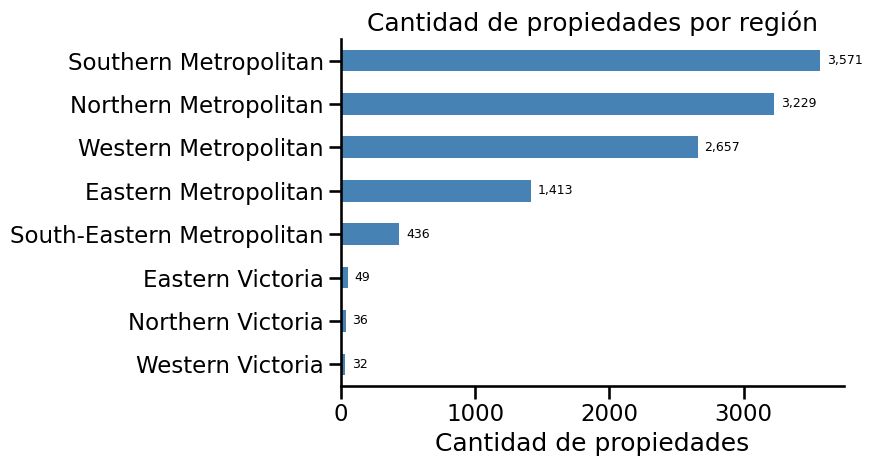

In [103]:
# Gráfico 1: Cantidad de propiedades por Regionname
resultado_q1_graf = resultado_q1.sort_values('cantidad_registros', ascending=True)

ax = resultado_q1_graf.plot(
    kind='barh',
    x='Regionname',
    y='cantidad_registros',
    legend=False,
    color='steelblue',
    figsize=(9, 5)
)

plt.title('Cantidad de propiedades por región')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')

# Agregar etiquetas al final de cada barra
for i, value in enumerate(resultado_q1_graf['cantidad_registros']):
    ax.text(
        value + 50,
        i,
        f'{value:,}',
        va='center',
        fontsize=9
    )

# Limpiar bordes
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

El gráfico muestra una distribución desigual de propiedades entre las regiones de Melbourne. Las regiones con mayor cantidad de registros son Southern Metropolitan, Northern Metropolitan y Western Metropolitan, cada una con más de 2.000 propiedades, lo que refleja una mayor concentración de observaciones en zonas metropolitanas.

En cambio, regiones como Eastern Victoria, Northern Victoria y Western Victoria presentan una cantidad mucho menor de registros, posiblemente por tratarse de zonas más periféricas o con menor actividad inmobiliaria registrada en el dataset.

Esta diferencia es importante porque las regiones con pocos registros pueden generar estimaciones menos robustas al analizar precios promedio. Por ese motivo, en consultas posteriores conviene considerar la cantidad de observaciones disponibles antes de interpretar los valores promedio.

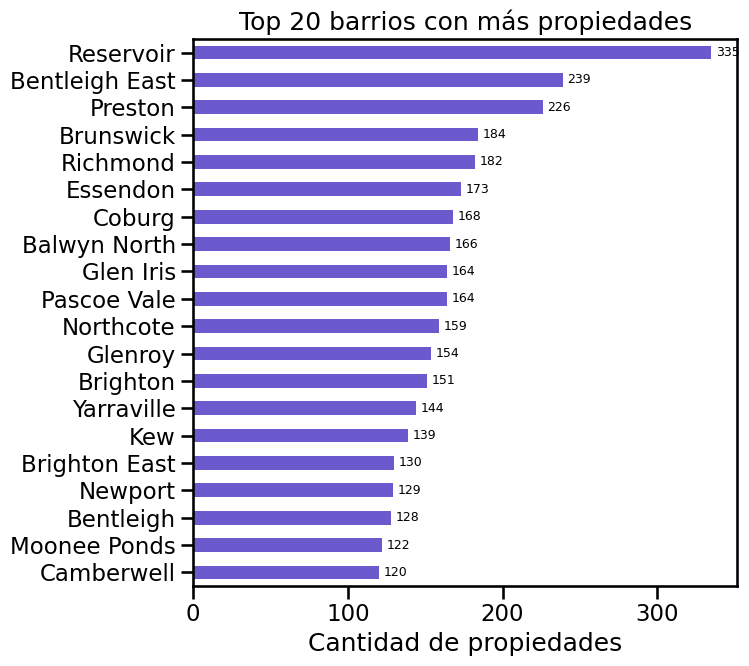

In [104]:
# Gráfico 2: Top 20 barrios con más propiedades
resultado_q2_top20 = resultado_q2.head(20)

resultado_q2_top20.plot(
    kind='barh',
    x='Suburb',
    y='cantidad_registros',
    color='slateblue',
    legend=False,
    figsize=(8, 7)
)

plt.title('Top 20 barrios con más propiedades')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')
plt.gca().invert_yaxis()

for bar in plt.gca().patches:
    valor = bar.get_width()
    plt.gca().text(
        valor + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(valor)}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()


El gráfico muestra los 20 barrios con mayor cantidad de propiedades registradas en el dataset. Se observa que algunos barrios concentran una cantidad considerablemente mayor de registros, lo que indica que tienen mayor presencia dentro de la base analizada.

Estos barrios pueden representar zonas con mayor actividad inmobiliaria, mayor densidad residencial o simplemente una mejor cobertura dentro del dataset. Al mismo tiempo, esta concentración implica que los análisis realizados sobre estos barrios pueden ser más representativos que aquellos aplicados sobre barrios con pocos registros.

Este resultado también permite identificar qué zonas tienen mayor peso en el dataset y podrían influir más en los análisis generales de precios, tipos de propiedad y distribución geográfica.

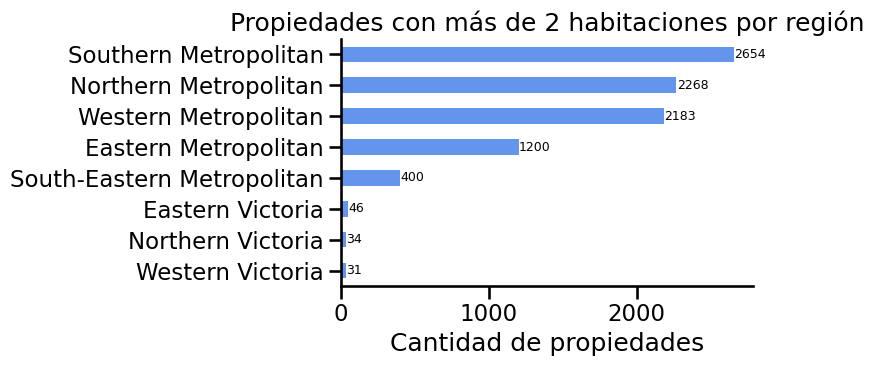

In [105]:
# Gráfico 3: Propiedades con más de 2 habitaciones por región
ax = resultado_q3.plot(
    kind='barh',
    x='Regionname',
    y='cantidad_propiedades_mas_2_rooms',
    color='cornflowerblue',
    legend=False,
    figsize=(8, 4)
)

plt.title('Propiedades con más de 2 habitaciones por región')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')
plt.gca().invert_yaxis()

ax.spines[['top', 'right']].set_visible(False)

for bar in plt.gca().patches:
    valor = bar.get_width()
    plt.gca().text(
        valor + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(valor)}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

El gráfico permite observar en qué regiones se concentra la mayor cantidad de propiedades con más de 2 habitaciones. Nuevamente, las regiones metropolitanas aparecen con mayor presencia, lo que sugiere una mayor disponibilidad de viviendas de tamaño medio o grande en esas zonas.

Este filtro permite diferenciar las propiedades más familiares o de mayor capacidad respecto de unidades más pequeñas. La distribución mantiene cierta relación con la cantidad total de registros por región, aunque ayuda a identificar específicamente dónde se concentran las propiedades con mayor cantidad de ambientes.

Las regiones con menor cantidad de registros también muestran menos propiedades con más de 2 habitaciones, por lo que su interpretación debe hacerse con cuidado.

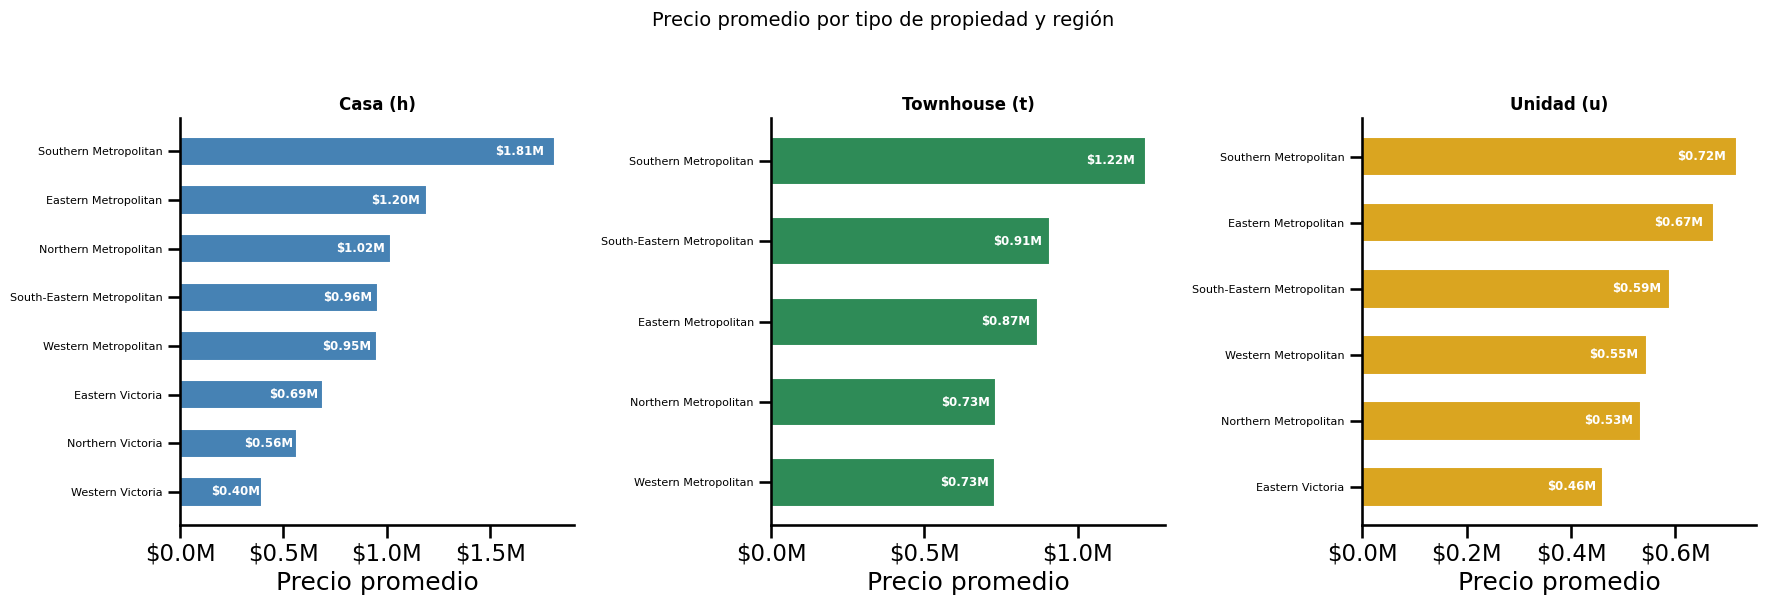

In [106]:
# Gráfico 4: Precio promedio por tipo de propiedad y región
millon_fmt = plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tipos = {
    'h': 'Casa (h)',
    't': 'Townhouse (t)',
    'u': 'Unidad (u)'
}

colores = {
    'h': 'steelblue',
    't': 'seagreen',
    'u': 'goldenrod'
}

for ax, (tipo, label) in zip(axes, tipos.items()):
    subset = (
        resultado_q4[resultado_q4['Type'] == tipo]
        .sort_values('precio_promedio', ascending=True)
    )

    bars = ax.barh(
        subset['Regionname'],
        subset['precio_promedio'],
        color=colores[tipo],
        edgecolor='white',
        height=0.6
    )

    for bar, val in zip(bars, subset['precio_promedio']):
        ax.text(
            bar.get_width() * 0.97,
            bar.get_y() + bar.get_height() / 2,
            f'${val/1e6:.2f}M',
            va='center',
            ha='right',
            fontsize=8.5,
            color='white',
            fontweight='bold'
        )

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Precio promedio')
    ax.xaxis.set_major_formatter(millon_fmt)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Precio promedio por tipo de propiedad y región', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

El gráfico compara el precio promedio según el tipo de propiedad y la región. En general, las casas (h) presentan precios promedio más elevados que las townhouses (t) y las unidades (u), lo cual es esperable porque suelen tener mayor superficie, terreno y características residenciales más amplias.

También se observan diferencias importantes entre regiones. Algunas zonas metropolitanas presentan precios promedio más altos, lo que puede estar asociado a mayor demanda, mejor ubicación, cercanía a servicios o mayor valorización inmobiliaria.

Este análisis permite ver que el precio no depende solamente de la región, sino también del tipo de propiedad. Por eso, comparar precios promedio sin separar por Type podría ocultar diferencias relevantes entre casas, townhouses y unidades.

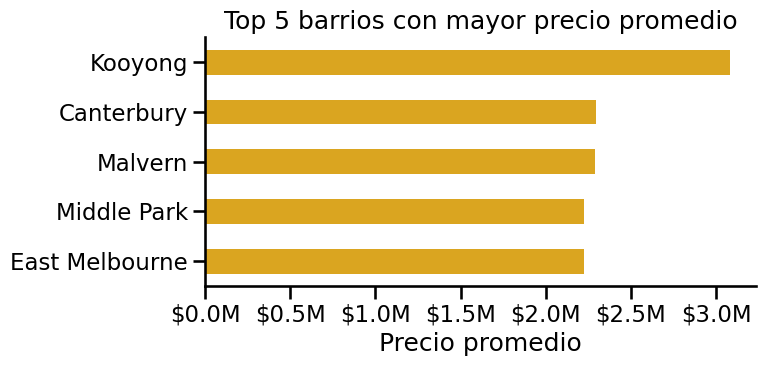

In [107]:
# Gráfico 5: Top 5 barrios con mayor precio promedio
ax = resultado_q5.plot(
    kind='barh',
    x='Suburb',
    y='precio_promedio',
    legend=False,
    color='goldenrod',
    figsize=(8, 4)
)

plt.title('Top 5 barrios con mayor precio promedio')
plt.xlabel('Precio promedio')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

El gráfico muestra los cinco barrios con mayor precio promedio de propiedades. Estos barrios se ubican en la parte superior del ranking porque sus propiedades registran valores medios más altos dentro del dataset.

Sin embargo, para que el ranking sea más confiable, es importante considerar la cantidad de registros disponibles por barrio. Si un barrio tiene muy pocas propiedades, un solo valor extremo puede elevar artificialmente el promedio. Por eso, es recomendable utilizar una condición como 'HAVING COUNT(*)>=10'.

De esta manera, el ranking se calcula solo sobre barrios con una cantidad mínima de observaciones, reduciendo el riesgo de interpretar como caro un barrio que aparece arriba únicamente por pocos casos atípicos.

In [108]:
# Mapa: distribución geográfica del Top 5 de barrios más caros
top5_suburbs = resultado_q5['Suburb'].tolist()

data_top5 = melb_df[
    melb_df['Suburb'].isin(top5_suburbs)
].copy()

fig = px.scatter_mapbox(
    data_top5,
    lat="Lattitude",
    lon="Longtitude",
    color="Suburb",
    size="Price",
    size_max=25,
    opacity=0.7,
    hover_name="Address",
    hover_data={
        "Price": True,
        "Rooms": True,
        "Type": True,
        "Lattitude": False,
        "Longtitude": False
    },
    zoom=9,
    height=700,
    mapbox_style="open-street-map",
    title="Top 5 barrios más caros — distribución geográfica"
)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    mapbox_bounds={
        "west": data_top5.Longtitude.min() - 0.1,
        "east": data_top5.Longtitude.max() + 0.1,
        "south": data_top5.Lattitude.min() - 0.1,
        "north": data_top5.Lattitude.max() + 0.1
    }
)

fig.show()

El mapa permite visualizar la ubicación geográfica de las propiedades pertenecientes a los barrios con mayor precio promedio. Esta representación complementa el ranking anterior, porque no solo muestra cuáles son los barrios más caros, sino también dónde se localizan dentro del área de Melbourne.

La visualización geográfica ayuda a identificar si los barrios de mayor precio se encuentran concentrados en una zona específica o si están distribuidos en distintos sectores. Además, permite observar la relación entre ubicación, precio y concentración de propiedades.

### Unificación de datasets

#### Intersección de datos

Antes de unir los conjuntos de datos, nos aseguramos de tener suficientes registros en común para agregar información relevante.

In [109]:
# Exploramos valores en comun
intersection = np.intersect1d(
    airbnb_df['zipcode'].values, melb_df['Postcode'].values, assume_unique=False)

print("Airbnb unique zipcodes:", len(airbnb_df['zipcode'].unique()))
print("Sales unique zipcodes:", len(melb_df['Postcode'].unique()))
print("Common zipcodes:", len(intersection))
print('')

print('Registros en Melbourne con zipcode en Airbnb:',
      melb_df['Postcode'].isin(intersection).sum() / len(melb_df))
print('Registros en Airbnb con zipcode en Melbourne:',
      airbnb_df['zipcode'].isin(intersection).sum() / len(airbnb_df))

Airbnb unique zipcodes: 248
Sales unique zipcodes: 194
Common zipcodes: 188

Registros en Melbourne con zipcode en Airbnb: 0.9985993171671189
Registros en Airbnb con zipcode en Melbourne: 0.9029919196331077


#### Exploración visual

Para asegurarnos de que las áreas representadas por ambos datasets son consitentes, representamos las coordenadas en un mapa usando Plotly.

In [110]:
# Exploracion visual: Distirbucion geografica de ambos datasets

# Muestreo de Melbourne y conversión de SaleYear a string (categórico)
data_melb = melb_df.sample(300, random_state=42).copy()
data_melb['SaleYear'] = data_melb['SaleYear'].astype(str)

# Limpieza y filtrado de Airbnb
airbnb_df['state_clean'] = airbnb_df['state'].str.strip().str.upper()
airbnb_df['state_clean'] = airbnb_df['state_clean'].replace({
    'VI': 'VIC',
    'VICTORIA': 'VIC',
    '維多利亞 VIC': 'VIC'
})
# Filtramos para asegurarnos de que solo graficamos la zona de interés (VIC)
data_airbnb = airbnb_df[airbnb_df['state_clean'] == 'VIC'].sample(300, random_state=42)


# CONSTRUCCIÓN DEL MAPA UNIFICADO

fig = go.Figure()

# Capa 1: Propiedades en Venta (Melbourne)
# Usamos un bucle para separar por año de venta y evitar el gradiente continuo
for year in sorted(data_melb['SaleYear'].unique()):
    df_year = data_melb[data_melb['SaleYear'] == year]

    fig.add_trace(go.Scattermapbox(
        lat=df_year['Lattitude'],
        lon=df_year['Longtitude'],
        mode='markers',
        marker=dict(
            size=8,
            opacity=0.7
        ),
        name=f'Venta Melb - {year}',
        text=df_year.apply(lambda r: f"Precio: ${r['Price']:,.0f}<br>Tipo: {r['Type']}<br>Barrio: {r['Suburb']}", axis=1),
        hoverinfo='text'
    ))

# Capa 2: Listings de Airbnb
fig.add_trace(go.Scattermapbox(
    lat=data_airbnb['latitude'],
    lon=data_airbnb['longitude'],
    mode='markers',
    marker=dict(
        size=6,
        color='gold', # Color fijo contrastante para diferenciarlo de las ventas
        opacity=0.6
    ),
    name='Airbnb Listings',
    text=data_airbnb.apply(lambda r: f"Precio/Noche: ${r['price']}<br>Barrio: {r['neighborhood']}", axis=1),
    hoverinfo='text'
))


# DISEÑO Y CONFIGURACIÓN DEL LAYOUT

# Calculamos el centro dinámico del mapa basado en los datos de Melbourne
center_lat = data_melb['Lattitude'].median()
center_lon = data_melb['Longtitude'].median()

fig.update_layout(
    title={
        'text': "<b>Análisis Inmobiliario en Melbourne: Ventas vs. Airbnb</b>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    mapbox=dict(
        style='open-street-map',
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9.5
    ),
    margin={"r": 10, "t": 60, "l": 10, "b": 10},
    height=650,
    legend=dict(
        title_text="<b>Capas de Datos</b>",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)" # Fondo semi-transparente para legibilidad
    )
)

fig.show()

#### Agrupación y unificación

Se renombran y agrupan las columnas de `airbnb_df` por zipcode usando diccionarios, cuyas *keys* son las columnas originales por agregar y los *values* son las operaciones.

In [111]:
# Verificacion de columnas contenidas en airbnb
airbnb_price_by_zipcode.columns

Index(['zipcode', 'airbnb_price_median', 'airbnb_record_count',
       'airbnb_weekly_price_median', 'airbnb_monthly_price_median'],
      dtype='object')

In [112]:
airbnb_price_by_zipcode[:3]

,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,0,120.0,146,780.0,3300.0
1,2010,40.0,1,NaN,NaN
2,2134,50.0,1,NaN,NaN


In [113]:
# Guardado del dataset en formato .csv
airbnb_price_by_zipcode.to_csv("airbnb_price_by_zipcode.csv", index=None)

In [114]:
# Unificacion del dataset de Melbourne con el de airbnb agrupado por zipcode
merged_sales_df = melb_df.merge(
    airbnb_price_by_zipcode, how='left',
    left_on='Postcode', right_on='zipcode'
)
merged_sales_df.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bathroom,...,Longtitude,Regionname,Propertycount,SaleYear,SaleMonth,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
3460,Newport,16 Blenheim Rd,3,h,1176000.0,S,hockingstuart,8.4,3015,1,...,144.86360,Western Metropolitan,5498,2016,6,3015.0,96.0,65.0,559.5,1974.0
1150,Brunswick,30 Charles St,4,h,1350000.0,S,Nelson,5.2,3056,1,...,144.96390,Northern Metropolitan,11918,2016,10,3056.0,77.0,446.0,525.0,2150.0
7343,Coburg,1/185 Moreland Rd,3,t,690000.0,SP,Nelson,6.7,3058,1,...,144.96481,Northern Metropolitan,11204,2017,6,3058.0,75.0,133.0,430.0,1700.0
7270,Bayswater,17 Orange Gr,3,h,700000.0,S,Biggin,23.2,3153,2,...,145.26673,Eastern Metropolitan,5030,2017,6,3153.0,50.5,16.0,952.0,3512.0
1574,Caulfield South,8 Lygon St,4,h,1774500.0,S,hockingstuart,9.3,3162,2,...,145.02540,Southern Metropolitan,5051,2016,5,3162.0,96.0,81.0,1190.0,4258.0


In [115]:
merged_sales_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'CouncilArea',
       'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'SaleYear',
       'SaleMonth', 'zipcode', 'airbnb_price_median', 'airbnb_record_count',
       'airbnb_weekly_price_median', 'airbnb_monthly_price_median'],
      dtype='object')

#### Validación

Se chequea que la cantidad de filas se mantuvo y que no aparecieron nulos inesperados en las columnas agregadas.

Se validan dimensiones básicas de calidad de datos:

- validez,
- completitud,
- integridad.

In [116]:
print(f"Filas antes: {len(melb_df)}")
print(f"Filas después: {len(merged_sales_df)}")
print(f"Nulls nuevos en airbnb_price_median: {merged_sales_df['airbnb_price_median'].isna().sum()}")

assert len(merged_sales_df) == len(melb_df), "El merge cambió el número de filas"
assert merged_sales_df["Price"].isna().sum() == 0, "Hay nulls inesperados en Price"
assert merged_sales_df["airbnb_price_median"].dropna().between(0, 10000).all(), "Precios fuera de rango"

Filas antes: 11423
Filas después: 11423
Nulls nuevos en airbnb_price_median: 16


In [117]:
merged_sales_df.to_csv("melb_data_extended.csv", index=None)

## Ejercicio 2 - Pandas:

Este ejercicio usa el archivo `airbnb_price_by_zipcode.csv` generado en el notebook `02.1 Combinación de datasets.ipynb`. Si no lo tenés, generarlo primero antes de comenzar esta parte.

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2. Mostrar la dispersión o distribución de las columnas seleccionadas.
 3. Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás


2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (¿por qué no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación. Si tuvieras que entrevistar a un experto inmobiliario para mapear barrios entre datasets, ¿qué 3 preguntas le harías para validar esa correspondencia?
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?


In [122]:
airbnb_price_by_zipcode.columns

Index(['zipcode', 'airbnb_price_median', 'airbnb_record_count',
       'airbnb_weekly_price_median', 'airbnb_monthly_price_median'],
      dtype='object')

In [123]:
airbnb_price_by_zipcode.head()

,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,0,120.0,146,780.0,3300.0
1,2010,40.0,1,NaN,NaN
2,2134,50.0,1,NaN,NaN
3,2582,104.0,1,NaN,NaN
4,3000,129.0,3367,857.0,3469.0


1- Se toma el DF con todos los valores incorporados. Hacemos un análisis ce correlación y vemos las columnas que tienen una correlación mayor a +0,2 con el precio de la unidad. Los que tengan un valor de correlación menor del mencionado no son consideradas relevantes.


In [124]:
airbnb_price_by_zipcode.describe()

,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
count,248.000000,248.000000,248.000000,185.000000,169.000000
mean,3494.391129,110.102823,92.318548,651.200000,2475.079882
std,1913.073652,60.562633,261.406379,343.193812,1496.435722
min,0.000000,37.000000,1.000000,133.000000,527.000000
25%,3071.750000,68.875000,8.750000,385.000000,1490.000000
50%,3147.500000,92.000000,27.000000,600.000000,2200.000000
75%,3509.250000,133.875000,74.000000,815.000000,3004.000000
max,30122.000000,317.000000,3367.000000,2000.000000,10060.000000


In [118]:
merged_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11423 entries, 0 to 11422
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Suburb                       11423 non-null  object 
 1   Address                      11423 non-null  object 
 2   Rooms                        11423 non-null  int64  
 3   Type                         11423 non-null  object 
 4   Price                        11423 non-null  float64
 5   Method                       11423 non-null  object 
 6   SellerG                      11423 non-null  object 
 7   Distance                     11423 non-null  float64
 8   Postcode                     11423 non-null  int64  
 9   Bathroom                     11423 non-null  int64  
 10  Car                          11423 non-null  int64  
 11  Landsize                     11423 non-null  float64
 12  CouncilArea                  11423 non-null  object 
 13  Lattitude       


 melb_numeric datos: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11423 entries, 0 to 11422
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rooms                        11423 non-null  int64  
 1   Price                        11423 non-null  float64
 2   Distance                     11423 non-null  float64
 3   Postcode                     11423 non-null  int64  
 4   Bathroom                     11423 non-null  int64  
 5   Car                          11423 non-null  int64  
 6   Landsize                     11423 non-null  float64
 7   Lattitude                    11423 non-null  float64
 8   Longtitude                   11423 non-null  float64
 9   Propertycount                11423 non-null  int64  
 10  SaleYear                     11423 non-null  int32  
 11  SaleMonth                    11423 non-null  int32  
 12  zipcode                      11407 non-null  float

/tmp/ipykernel_1009/1398111137.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




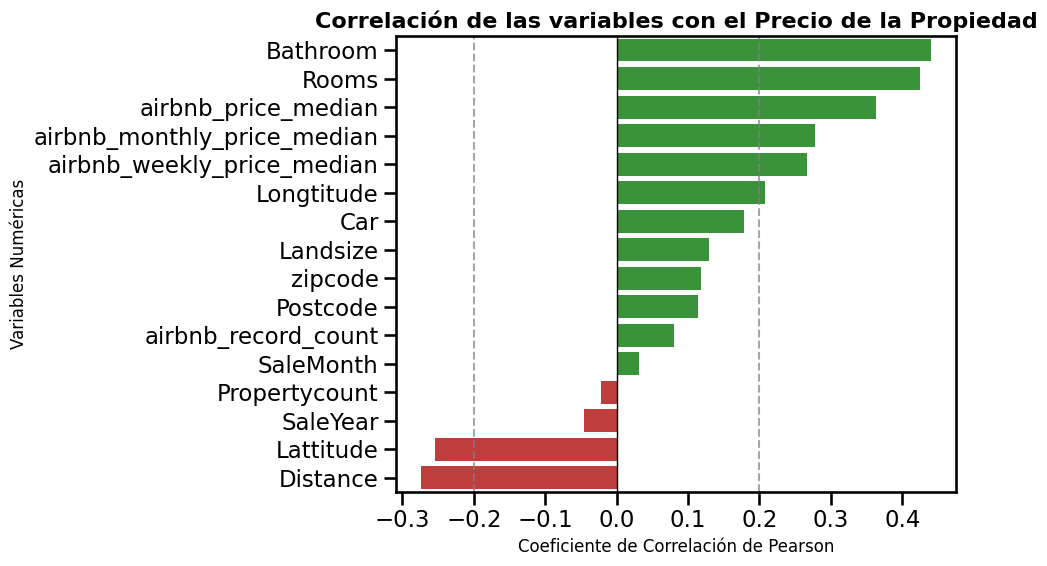


Columnas seleccionadas con correlación absoluta mayor o igual a 0.2:
['Bathroom', 'Rooms', 'airbnb_price_median', 'airbnb_monthly_price_median', 'airbnb_weekly_price_median', 'Longtitude', 'Lattitude', 'Distance', 'Price']


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que los valores numéricos lo sean
# Lista de columnas que por naturaleza de este conjunto de datos deberían ser numéricas
cols_to_numeric = ['Rooms', 'Price', 'Distance', 'Postcode', 'Bathroom',
                   'Car', 'Landsize', 'Propertycount', 'SaleYear', 'Lattitude', 'Longtitude',
                   'SaleMonth', 'zipcode', 'airbnb_price_median',
                   'airbnb_record_count', 'airbnb_weekly_price_median', 'airbnb_monthly_price_median']

# Forzamos la conversión a numérico. Los valores ilegibles se convertirán en NaN (errors='coerce')
for col in cols_to_numeric:
    if col in merged_sales_df.columns:
        merged_sales_df[col] = pd.to_numeric(merged_sales_df[col], errors='coerce')

# Filtramos solo las columnas numéricas para evitar errores en la matriz de correlación
melb_numeric = merged_sales_df.select_dtypes(include=['number', 'float64', 'int64']).copy()

# Eliminamos filas donde el precio es nulo, ya que no nos sirven para calcular correlación
melb_numeric = melb_numeric.dropna(subset=['Price'])
print ("\n melb_numeric datos: \n")
melb_numeric.info()




# 3. Calcular los coeficientes de correlación
correlaciones = melb_numeric.corr()

# Aislamos la columna 'Price', quitamos la auto-correlación (Price vs Price = 1) y ordenamos
corr_con_precio = correlaciones['Price'].drop('Price').sort_values(ascending=False)

# 4. Generar el gráfico de coeficientes
plt.figure(figsize=(10, 6))

# Asignamos colores: un color para correlación positiva y otro para negativa
colores = ['#2ca02c' if valor > 0 else '#d62728' for valor in corr_con_precio.values]

sns.barplot(x=corr_con_precio.values, y=corr_con_precio.index, palette=colores)

# Configuración estética del gráfico
plt.title('Correlación de las variables con el Precio de la Propiedad', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Variables Numéricas', fontsize=12)

# Línea central en cero
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Líneas guía de umbral (ej. 0.2 y -0.2) para ayudar a decidir qué descartar
umbral_visual = 0.2
plt.axvline(x=umbral_visual, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(x=-umbral_visual, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Selección final de columnas
# Seleccionamos automáticamente aquellas que superan el umbral (ya sea positivo o negativo)
columnas_seleccionadas = corr_con_precio[abs(corr_con_precio) >= umbral_visual].index.tolist()

# Agregamos 'Price' de vuelta a la lista, ya que es nuestro target
columnas_seleccionadas.append('Price')

print(f"\nColumnas seleccionadas con correlación absoluta mayor o igual a {umbral_visual}:")
print(columnas_seleccionadas)

# Si deseas aplicar esta selección al DataFrame original:
# melb_df_final = melb_df[columnas_seleccionadas]

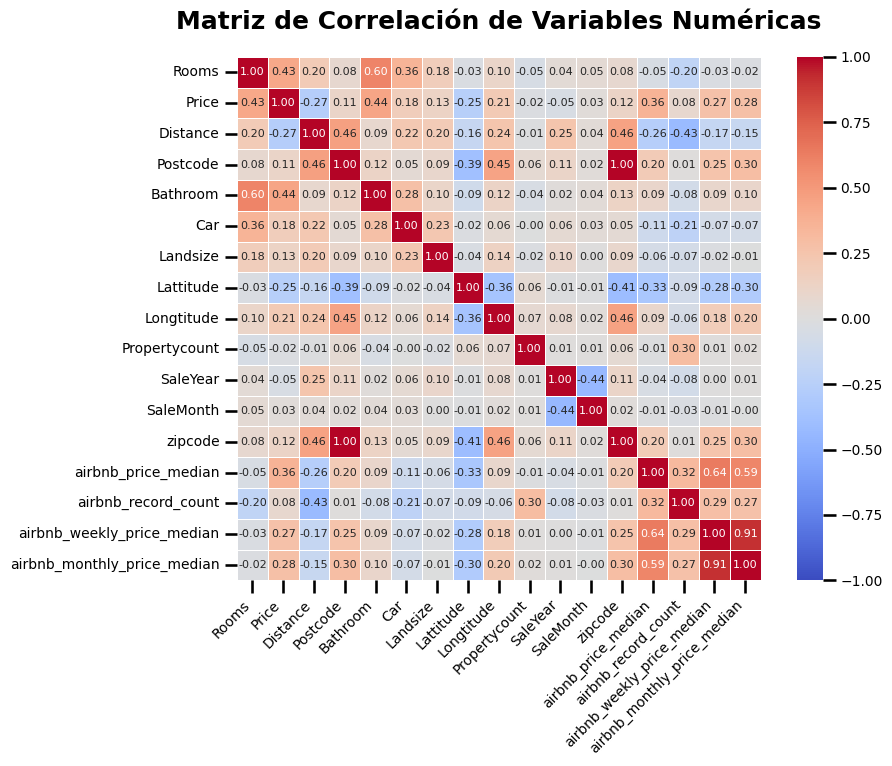

In [120]:
# 6. Generar la matriz de Heatmap para todas las variables
plt.figure(figsize=(10, 8))

# Creamos el heatmap
ax =sns.heatmap(
    correlaciones,
    annot=True,          # Muestra los valores numéricos de correlación en cada celda
    annot_kws={"size": 8},
    fmt=".2f",           # Formatea los números a 2 decimales para mayor legibilidad
    cmap="coolwarm",     # Paleta de colores divergente (rojo para +, azul para -)
    vmin=-1, vmax=1,     # Fija los límites de la escala de colores de -1 a 1
    center=0,            # Centra el color blanco/neutro en el 0
    linewidths=0.5,      # Agrega una pequeña línea de separación entre celdas
    square=True          # Fuerza que las celdas sean cuadradas
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

# Configuración estética
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


In [121]:
columnas_seleccionadas = []

for columna, valor_corr in corr_con_precio.items():
    if abs(valor_corr) > 0.2:
        columnas_seleccionadas.append(columna)

if 'Price' not in columnas_seleccionadas:
    columnas_seleccionadas.append('Price')

print("Columnas con correlación absoluta mayor a 0.2:")
print(columnas_seleccionadas)

Columnas con correlación absoluta mayor a 0.2:
['Bathroom', 'Rooms', 'airbnb_price_median', 'airbnb_monthly_price_median', 'airbnb_weekly_price_median', 'Longtitude', 'Lattitude', 'Distance', 'Price']


### Criterios de evaluación
Se evaluará principalmente:
- claridad del código,
- justificación de las decisiones de curación,
- coherencia entre el análisis realizado y las conclusiones,
- presencia de validaciones después de operaciones críticas como merges o cargas a base.

No se espera una única solución correcta, pero sí que las decisiones estén justificadas y sean consistentes con los datos.


## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

## Ejercicios opcionales:

El notebook `02.2 ETLs-DAGs.ipynb` tiene un esqueleto de referencia para guiarse.

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)

3. Bonus: embeddings y búsqueda semántica con descripciones de AirBnB.
   - Usar `sentence-transformers` para codificar descripciones textuales de propiedades.
   - Tomar un subconjunto chico de descripciones, calcular embeddings y encontrar el par más similar con similitud coseno.
   - Reflexionar: ¿por qué este resultado no se puede lograr con `LIKE '%keyword%'` en SQL? ¿Qué pasa si dos propiedades son similares pero usan palabras distintas? ¿Qué representan los 384 números del embedding?

4. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?


5. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?

Ejemplo conceptual:


In [125]:
import anthropic
import json

client = anthropic.Anthropic()

# Valores únicos con posibles inconsistencias
council_values = melb_df['CouncilArea'].dropna().unique().tolist()

message = client.messages.create(
    model="claude-opus-4-7",
    max_tokens=1024,
    messages=[{
        "role": "user",
        "content": f"""Estos son los valores únicos de la columna CouncilArea en un dataset de propiedades de Melbourne:
{council_values}

Identificá: (1) duplicados con distinta capitalización o spelling,
 (2) valores que parecen errores, (3) valores que podrían agruparse.
Respondé en JSON con la estructura: {{"estandarizado": {{"valor_original": "valor_correcto"}}}}"""
    }]
)

mapping = json.loads(message.content[0].text)
melb_df['CouncilArea_clean'] = melb_df['CouncilArea'].map(
    mapping.get('estandarizado', {})
).fillna(melb_df['CouncilArea'])


ModuleNotFoundError: No module named 'anthropic'